# Optimal quoting — illiquid underlying (Theorem 2)

Phase 2, continued: Stoikov & Sağlam (2009), Section III / Appendix B (one-period model). Builds directly on [`optimal_quoting_theorem1.ipynb`](optimal_quoting_theorem1.ipynb) — same surface, same calibrated option liquidity — but drops Theorem 1's assumption that the underlying trades continuously and costlessly.

**What changes vs. Theorem 1:** the dealer must now also quote the *stock* (illiquid enough that continuous delta-hedging isn't free), so premiums on both legs tilt with the dealer's **net Delta** (`q_s + q_o*Delta`) instead of staying flat. That's the paper's central new result here — Theorem 1's quotes never moved with inventory; Theorem 2's do, by construction.

This notebook:
1. Reuses the Phase 1 surface and the option-side fill-intensity calibration from the Theorem 1 notebook
2. Calibrates the **stock**-side intensity (`A`, `B`) from BTC-PERPETUAL's trade tape — the same `market_making.calibration` machinery, generalized to a USD-quoted instrument
3. Estimates realized (physical) volatility from that same tape — the risk term needs *physical* vol, not the option's implied vol
4. Calibrates **gamma** (risk aversion) two ways: inverting real observed spreads (which turns out not to work here — a real, informative finding, not a bug) and, the one actually used, backing it out of a stated inventory risk limit
5. Computes `quoting.quote_theorem2` for a chosen inventory scenario
6. Sweeps inventory to show the tilt directly, and contrasts it with Theorem 1's flat quotes

New code lives in `src/market_making/quoting.py` (`quote_theorem2`, `implied_gamma_from_spread`, `implied_gamma_from_risk_limit`) and the `price_in_underlying_units`/`realized_vol` additions to `src/market_making/calibration.py`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('../src/vol_surface'))

import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bs
import surface
import data
from market_making import quoting, calibration

%matplotlib inline
np.set_printoptions(precision=6, suppress=True)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 1. Build the vol surface and pick an option

Same Phase 1 pipeline as the Theorem 1 notebook.

In [2]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    surf = surface.run_pipeline('BTC')

r, q = 0.0, 0.0
T0 = float(surf.maturities[len(surf.maturities) // 2])
F0 = float(np.interp(T0, surf.maturities, surf.forwards))
K0 = round(F0 / 500) * 500
S0 = F0
sigma0 = surf.implied_vol(K0, T0)
mid0 = float(bs.price(S0, K0, T0, r, q, sigma0, 'C'))
delta0 = float(bs.delta(S0, K0, T0, r, q, sigma0, 'C'))

print(f"S={S0:.0f}  K={K0:.0f}  T={T0:.4f}  implied_vol={sigma0:.4f}")
print(f"mid={mid0:,.2f}  delta={delta0:.4f}")

S=64566  K=64500  T=0.2191  implied_vol=0.3737
mid=4,531.16  delta=0.5372


## 2. Calibrate the option-side intensity

Identical to the Theorem 1 notebook's fill-intensity calibration: pool trades across the most active instruments on the chain, fit a relative survival curve separately for bid and ask, then rescale to this option's own mid.

In [3]:
raw_book = data.fetch_book_summary('BTC')
top_instruments = [
    rec['instrument_name'] for rec in sorted(raw_book.to_dict('records'), key=lambda x: -(x.get('volume') or 0))[:30]
    if (rec.get('volume') or 0) > 0
]
option_trades = calibration.fetch_trades_multi(top_instruments, count_each=1000)
option_fit = calibration.calibrate_intensity(option_trades, min_trades_per_side=20, n_bins=15)

option_bid_intensity = option_fit.bid.intensity.to_absolute(mid0)
option_ask_intensity = option_fit.ask.intensity.to_absolute(mid0)
print(f"option: pooled {len(option_trades)} trades across {len(top_instruments)} instruments")
print(f"option max premium (bid/ask) = {option_bid_intensity.max_premium:.2f} / {option_ask_intensity.max_premium:.2f}")

# real observed option spread near K0/T0 -- used by Section 4's gamma calibration
chain_raw = data.build_chain(raw_book)
chain_raw['width'] = chain_raw['ask'] - chain_raw['bid']
nearby = chain_raw[(chain_raw['T'].sub(T0).abs() < 0.02) & (chain_raw['strike'].sub(K0).abs() < 3000)]
real_option_spread = float(nearby['width'].median()) if not nearby.empty else None
print(f"real observed option spread nearby (n={len(nearby)}) = {real_option_spread}")

option: pooled 1290 trades across 30 instruments
option max premium (bid/ask) = 479.98 / 519.59


real observed option spread nearby (n=12) = 96.84887999999978


## 3. Calibrate the stock-side intensity and realized vol

BTC-PERPETUAL is USD-quoted (unlike options, which Deribit prices in BTC), so `price`/`mark_price` need no `index_price` conversion — that's what `price_in_underlying_units=False` selects in `add_fill_distance`/`calibrate_intensity`. It's also liquid enough on its own that no pooling across instruments is needed: it alone prints far more trades per hour than the entire option chain combined (~1000 trades in under an hour, vs. ~1000 pooled across 30 option instruments over a full day).

The same trade tape also gives a **realized volatility** estimate via `calibration.realized_vol` — the *physical* vol driving the dealer's inventory risk in Theorem 2, as opposed to `sigma0` (the option's *implied* vol used only for pricing/Greeks above). They need not agree, and it's worth checking how far apart they are.

In [4]:
perp_trades = calibration.fetch_trades('BTC-PERPETUAL', count=1000)
window_min = (perp_trades['timestamp'].max() - perp_trades['timestamp'].min()) / 1000 / 60
print(f"BTC-PERPETUAL: {len(perp_trades)} trades over {window_min:.1f} minutes")

stock_fit = calibration.calibrate_intensity(
    perp_trades, min_trades_per_side=20, n_bins=15, price_in_underlying_units=False
)
stock_bid_intensity = stock_fit.bid.intensity.to_absolute(S0)
stock_ask_intensity = stock_fit.ask.intensity.to_absolute(S0)
print(f"stock max premium (bid/ask) = {stock_bid_intensity.max_premium:.2f} / {stock_ask_intensity.max_premium:.2f}")

sigma_risk = calibration.realized_vol(perp_trades, freq='1min')
print(f"\nrealized vol (from {window_min:.0f}min of BTC-PERPETUAL trades) = {sigma_risk:.4f}")
print(f"option implied vol (surface, same strike/expiry)             = {sigma0:.4f}")
print("(a short realized-vol window is noisy -- see the wrap-up note at the end)")

# real observed stock spread -- used by Section 4's gamma calibration
ticker = requests.get('https://www.deribit.com/api/v2/public/ticker',
                       params={'instrument_name': 'BTC-PERPETUAL'}, timeout=10).json()['result']
real_stock_spread = float(ticker['best_ask_price'] - ticker['best_bid_price'])
print(f"\nreal observed BTC-PERPETUAL top-of-book spread = {real_stock_spread:.2f}")

BTC-PERPETUAL: 1000 trades over 20.4 minutes
stock max premium (bid/ask) = 2.12 / 3.16

realized vol (from 20min of BTC-PERPETUAL trades) = 0.1241
option implied vol (surface, same strike/expiry)             = 0.3737
(a short realized-vol window is noisy -- see the wrap-up note at the end)



real observed BTC-PERPETUAL top-of-book spread = 0.50


## 4. Calibrate gamma

Two approaches, both inverting Theorem 2's flat-inventory (`net_delta=0`) spread formula
`spread = max_premium + gamma * sigma_risk^2 * horizon * S^2 * leg_scale^2`:

**(a) Invert against the real observed spread.** This is the literal "calibrate gamma from market data" approach -- but check the sign of the result before trusting it: `intensity.max_premium` (the risk-*neutral*, `gamma=0` spread already implied by the fitted fill-intensity curve alone) has to be *narrower* than the real spread for a valid (non-negative) gamma to exist. It usually isn't, here -- the earlier Theorem 1 notebook already found the calibrated option spread came out ~5x *wider* than the real market, and the same pattern shows up on the stock leg below. That's not a bug: the fitted intensity represents a single monopolistic dealer's revenue-maximizing spread (fit from trade prints that walk through real depth), while the real top-of-book reflects many competing dealers -- there's no reason those two numbers should agree, and inverting for gamma here will show it directly.

**(b) Back out gamma from a stated risk limit instead.** `gamma` is a genuine preference parameter -- unlike `A`/`B`/`C`/`D`, there's no fill-rate curve to fit it against. The standard practical way to set it: state "how much net Delta can I hold before I go maximally aggressive on one side" (a risk limit), then solve for the `gamma` consistent with that. This can't hit the sign problem above, since it targets the model's own saturation point rather than an external competitive benchmark it may never reach. **This is the value actually used below.**

In [5]:
horizon = 1 / 365  # 1-day risk-review window (still a chosen design parameter -- see wrap-up)

# (a) invert against real spreads -- report honestly, even if negative
gamma_from_stock_spread = quoting.implied_gamma_from_spread(
    stock_bid_intensity, real_stock_spread, sigma_risk, S0, horizon, leg_scale=1.0
)
gamma_from_option_spread = None
if real_option_spread is not None:
    gamma_from_option_spread = quoting.implied_gamma_from_spread(
        option_bid_intensity, real_option_spread, sigma_risk, S0, horizon, leg_scale=delta0
    )
print(f"gamma implied by real stock spread  = {gamma_from_stock_spread:.3e}"
      f"{'  <-- negative: model already wider than the real market, see markdown above' if gamma_from_stock_spread < 0 else ''}")
if gamma_from_option_spread is not None:
    print(f"gamma implied by real option spread = {gamma_from_option_spread:.3e}"
          f"{'  <-- negative: same story' if gamma_from_option_spread < 0 else ''}")

# (b) back out gamma from a stated risk limit -- this is what the rest of the notebook uses
net_delta_limit = 20.0  # policy choice: fully aggressive on one side once net Delta reaches 20 BTC-equivalent
gamma = quoting.implied_gamma_from_risk_limit(
    stock_bid_intensity, net_delta_limit, sigma_risk, S0, horizon, leg_scale=1.0
)
print(f"\ngamma implied by a {net_delta_limit:.0f}-BTC net-Delta risk limit = {gamma:.3e}  <-- used below")

gamma implied by real stock spread  = -9.222e-06  <-- negative: model already wider than the real market, see markdown above
gamma implied by real option spread = -7.544e-03  <-- negative: same story

gamma implied by a 20-BTC net-Delta risk limit = 3.093e-07  <-- used below


## 5. A single Theorem 2 quote

Using the calibrated `gamma` and `horizon` from Section 4.

In [6]:
quote = quoting.quote_theorem2(
    S0, K0, T0, r, q, sigma0, 'C',
    stock_bid_intensity, option_bid_intensity,
    gamma=gamma, sigma_risk=sigma_risk, horizon=horizon,
    q_s=3.0, q_o=20.0,
)
print(f"inventory: q_s=3.0 shares, q_o=20.0 lots  ->  net_delta={quote.net_delta:.3f}\n")
print(f"stock   bid/ask = {quote.bid_stock_price:,.2f} / {quote.ask_stock_price:,.2f}  "
      f"(premiums {quote.bid_stock_premium:.3f} / {quote.ask_stock_premium:.3f})")
print(f"option  bid/ask = {quote.bid_option_price:,.2f} / {quote.ask_option_price:,.2f}  "
      f"(premiums {quote.bid_option_premium:.2f} / {quote.ask_option_premium:.2f})")

inventory: q_s=3.0 shares, q_o=20.0 lots  ->  net_delta=13.743

stock   bid/ask = 64,564.09 / 64,566.27  (premiums 1.837 / 0.341)
option  bid/ask = 4,290.77 / 4,770.76  (premiums 240.40 / 239.59)


## 6. The tilt, directly: sweep stock inventory

Holding `q_o=0`, sweep `q_s` and watch the stock premiums move -- this is exactly what Theorem 1 could never show (its premiums were provably flat across the identical sweep in the previous notebook).

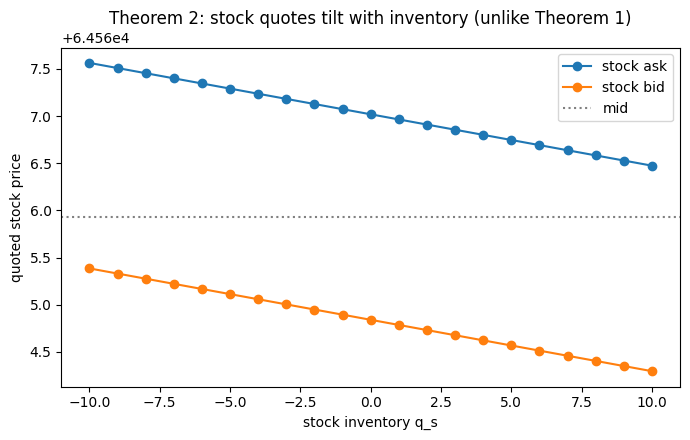

In [7]:
q_s_grid = np.linspace(-10, 10, 21)
rows = []
for q_s in q_s_grid:
    qt = quoting.quote_theorem2(S0, K0, T0, r, q, sigma0, 'C', stock_bid_intensity, option_bid_intensity,
                                 gamma=gamma, sigma_risk=sigma_risk, horizon=horizon, q_s=q_s, q_o=0.0)
    rows.append(dict(q_s=q_s, ask_stock=qt.ask_stock_premium, bid_stock=qt.bid_stock_premium,
                      ask_stock_price=qt.ask_stock_price, bid_stock_price=qt.bid_stock_price))
sweep_stock = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_stock.q_s, sweep_stock.ask_stock_price, 'o-', label='stock ask')
ax.plot(sweep_stock.q_s, sweep_stock.bid_stock_price, 'o-', label='stock bid')
ax.axhline(S0, color='gray', linestyle=':', label='mid')
ax.set_xlabel('stock inventory q_s')
ax.set_ylabel('quoted stock price')
ax.set_title('Theorem 2: stock quotes tilt with inventory (unlike Theorem 1)')
ax.legend()
plt.tight_layout()

## 7. Sweep option inventory instead

Holding `q_s=0`, sweep `q_o`. Net Delta grows with `q_o` (via `q_o * Delta`), so both legs should tilt -- but watch the relative magnitude: the paper's own finding (Section III's numerical example) is that a risk-averse dealer leans on the **stock** to absorb Delta risk far more than on the option itself. Check whether that holds here too.

stock ask premium range over the sweep:  2.123
option ask premium range over the sweep: 1.571
-> the dealer absorbs Delta risk mostly through the stock quotes


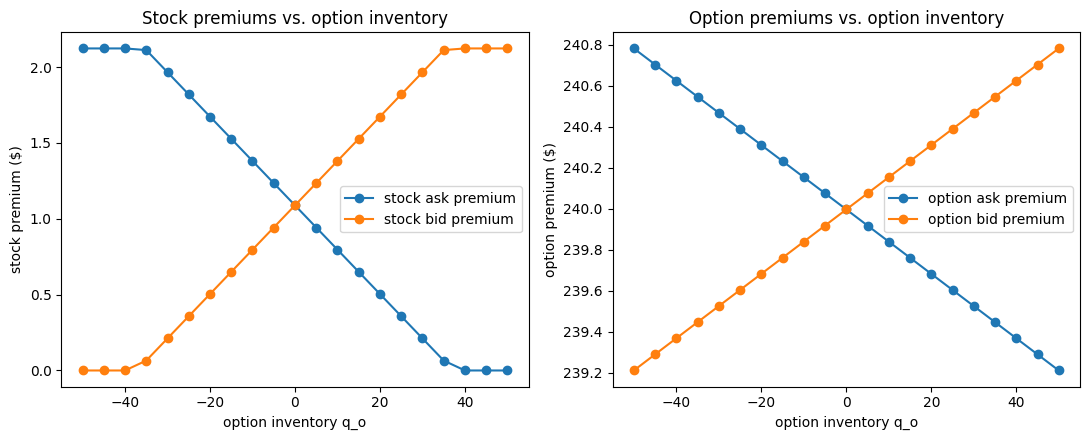

In [8]:
q_o_grid = np.linspace(-50, 50, 21)
rows = []
for q_o in q_o_grid:
    qt = quoting.quote_theorem2(S0, K0, T0, r, q, sigma0, 'C', stock_bid_intensity, option_bid_intensity,
                                 gamma=gamma, sigma_risk=sigma_risk, horizon=horizon, q_s=0.0, q_o=q_o)
    rows.append(dict(q_o=q_o, net_delta=qt.net_delta,
                      ask_stock=qt.ask_stock_premium, bid_stock=qt.bid_stock_premium,
                      ask_option=qt.ask_option_premium, bid_option=qt.bid_option_premium))
sweep_option = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(sweep_option.q_o, sweep_option.ask_stock, 'o-', label='stock ask premium')
axes[0].plot(sweep_option.q_o, sweep_option.bid_stock, 'o-', label='stock bid premium')
axes[0].set_xlabel('option inventory q_o'); axes[0].set_ylabel('stock premium ($)')
axes[0].set_title('Stock premiums vs. option inventory'); axes[0].legend()

axes[1].plot(sweep_option.q_o, sweep_option.ask_option, 'o-', label='option ask premium')
axes[1].plot(sweep_option.q_o, sweep_option.bid_option, 'o-', label='option bid premium')
axes[1].set_xlabel('option inventory q_o'); axes[1].set_ylabel('option premium ($)')
axes[1].set_title('Option premiums vs. option inventory'); axes[1].legend()
plt.tight_layout()

stock_swing = sweep_option.ask_stock.max() - sweep_option.ask_stock.min()
option_swing = sweep_option.ask_option.max() - sweep_option.ask_option.min()
print(f"stock ask premium range over the sweep:  {stock_swing:.3f}")
print(f"option ask premium range over the sweep: {option_swing:.3f}")
print(f"-> the dealer absorbs Delta risk mostly through the {'stock' if stock_swing > option_swing else 'option'} quotes")

## What this doesn't cover yet

This is still the **one-period** model (Theorem 2 / Appendix B): quotes are set once for a single upcoming risk window, given whatever inventory the dealer holds *right now*. See [`optimal_quoting_theorem3.ipynb`](optimal_quoting_theorem3.ipynb) for the multi-period extension (Theorem 3), which lets the tilt sensitivity itself evolve through the day via a backward recursion -- Theorem 2 here is that recursion's terminal (last-session) case.

Also still open:
- **Section IV (stochastic vol + jump risk, Theorems 4-5):** needs a *history* of fitted surfaces to estimate vol-of-implied-vol, not a single snapshot.
- **A real inventory tracker:** `q_s`/`q_o` are swept as parameters here, same as Theorem 1 -- nothing persists a live position between quotes yet.

Other caveats specific to this notebook:
- `horizon` is still a **chosen design parameter**, not calibrated -- gamma and horizon only ever appear as the product `gamma*horizon` in this model, so no amount of spread data can identify both separately (see `implied_gamma_from_spread`'s docstring). Fixing `horizon` and solving for `gamma` is the best this data can do.
- The `net_delta_limit` behind the risk-limit calibration is itself a stated policy choice, not fit from data -- a real desk would set it from actual risk limits, not a notebook's illustrative number.
- The realized-vol estimate above comes from whatever short window of recent BTC-PERPETUAL trades the API returned (well under an hour) -- that's a noisy, small-sample estimate of a physical vol that itself varies over time, and it visibly disagreed with the option's own implied vol in Section 3. A production version would use a longer, rolling realized-vol window rather than a single snapshot.
- Stock- and option-side liquidity are both real calibrations, but they're still each a single linear fit to a recent trade-tape snapshot -- the same non-stationarity caveat from the Theorem 1 notebook applies to both.